# PMDARIMA API Demonstration

This notebook introduces the PMDARIMA API for time-series forecasting on the 
**Individual Household Electric Power Consumption dataset**.

It demonstrates:
- Data loading and preprocessing using `pmdarima_utils.py`
- Splitting time-series data into training and testing sets
- Initializing an ARIMA model using `pmdarima.auto_arima`
- Generating basic forecasts

For detailed explanation, refer to the documentation file  
👉 [`pmdarima.API.md`](./pmdarima.API.md)

In [5]:
# %load_ext autoreload
# %autoreload 2
# %matplotlib inline

import logging
import matplotlib.pyplot as plt
import pmdarima as pm
from pmdarima_utils import load_energy_data, split_train_test

# Initialize logger
logging.basicConfig(level=logging.INFO)
_LOG = logging.getLogger(__name__)
_LOG.info("Starting PMDARIMA API demonstration notebook.")

INFO:__main__:Starting PMDARIMA API demonstration notebook.


## 1️⃣ Load and preprocess dataset
We’ll load the dataset using the `load_energy_data()` utility from `pmdarima_utils.py`.
The function combines `Date` and `Time` columns into a datetime index, 
handles missing values, and resamples the data hourly.

In [18]:
# Load dataset
data_path = "data/household_power_consumption.txt"
df = load_energy_data(data_path)

print("Dataset shape:", df.shape)
df.head()

INFO:pmdarima_utils:Loading dataset from data/household_power_consumption.txt
INFO:pmdarima_utils:Initial dataset shape: (2075259, 9)
INFO:pmdarima_utils:After resampling: (34168, 7)


Dataset shape: (34168, 7)


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
datetime,,,,,,,
2006-12-16 17:00:00,4.222889,0.229000,234.643889,18.100000,0.0,0.527778,16.861111
2006-12-16 18:00:00,3.632200,0.080033,234.580167,15.600000,0.0,6.716667,16.866667
2006-12-16 19:00:00,3.400233,0.085233,233.232500,14.503333,0.0,1.433333,16.683333
2006-12-16 20:00:00,3.268567,0.075100,234.071500,13.916667,0.0,0.000000,16.783333
2006-12-16 21:00:00,3.056467,0.076667,237.158667,13.046667,0.0,0.416667,17.216667


## 2️⃣ Split data into training and testing sets
We’ll use the helper function `split_train_test()` defined in `pmdarima_utils.py` 
to separate the data for model training and evaluation.

In [7]:
train, test = split_train_test(df)

print("Train size:", len(train), " | Test size:", len(test))
train.tail(), test.head()

INFO:pmdarima_utils:Splitting dataset with train ratio = 0.80
INFO:pmdarima_utils:Train size: 27334 | Test size: 6834


Train size: 27334  | Test size: 6834


(                     Global_active_power  Global_reactive_power     Voltage  \
 datetime                                                                      
 2010-02-05 00:00:00             1.706567               0.044767  242.774833   
 2010-02-05 01:00:00             1.577800               0.068867  243.125000   
 2010-02-05 02:00:00             0.986267               0.046933  244.813333   
 2010-02-05 03:00:00             0.404167               0.147100  246.292333   
 2010-02-05 04:00:00             0.378000               0.133000  246.127333   
 
                      Global_intensity  Sub_metering_1  Sub_metering_2  \
 datetime                                                                
 2010-02-05 00:00:00          7.013333             0.0        0.000000   
 2010-02-05 01:00:00          6.460000             0.0        0.000000   
 2010-02-05 02:00:00          4.066667             0.0        0.000000   
 2010-02-05 03:00:00          1.813333             0.0        0.9833

## 3️⃣ Train PMDARIMA model
We’ll use the `auto_arima()` API to automatically select the best ARIMA parameters 
based on AIC/BIC scores.

In [9]:
# Fit an Auto-ARIMA model
_LOG.info("Training PMDARIMA model...")

model = pm.auto_arima(
    train["Global_active_power"],   # target variable
    seasonal=False,
    stepwise=True,
    suppress_warnings=True,
    error_action="ignore",
    trace=False
)

_LOG.info("Model training completed.")
print(model.summary())

INFO:__main__:Training PMDARIMA model...
INFO:__main__:Model training completed.


                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                27334
Model:               SARIMAX(0, 1, 3)   Log Likelihood              -27169.882
Date:                Mon, 10 Nov 2025   AIC                          54347.765
Time:                        02:41:41   BIC                          54380.628
Sample:                             0   HQIC                         54358.356
                              - 27334                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.2817      0.005    -61.656      0.000      -0.291      -0.273
ma.L2         -0.3878      0.005    -85.660      0.000      -0.397      -0.379
ma.L3         -0.3026      0.005    -60.865      0.0

## 4️⃣ Forecast on test data
We’ll generate a forecast for the next N steps equal to the test length.

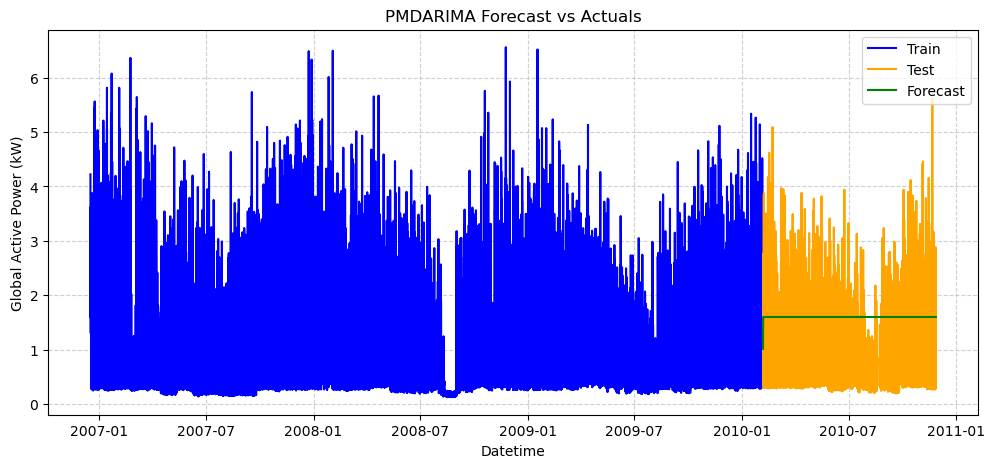

In [14]:
n_periods = len(test)
forecast = model.predict(n_periods=n_periods)
forecast_index = test.index

import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="statsmodels")
warnings.filterwarnings("ignore", category=FutureWarning, module="statsmodels")

# Plot results
plt.figure(figsize=(12, 5))
plt.plot(train.index, train["Global_active_power"], label="Train", color="blue")
plt.plot(test.index, test["Global_active_power"], label="Test", color="orange")
plt.plot(forecast_index, forecast, label="Forecast", color="green")
plt.title("PMDARIMA Forecast vs Actuals")
plt.xlabel("Datetime")
plt.ylabel("Global Active Power (kW)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

## 5️⃣ Summary
This notebook demonstrates the **PMDARIMA API workflow**:
- Data preprocessing with `pmdarima_utils`
- Model training using `auto_arima`
- Forecast visualization and interpretation

Next steps will be covered in `pmdarima.example.ipynb`, 
which extends this pipeline with performance metrics and hyperparameter tuning.